In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import os
import glob
import re

# Set plot style
sns.set_theme(style="whitegrid")

# Load Data

We will load the participant data files from the `BRSM data csv/` directory.
Each file represents a participant's session.
We extract the condition (AB/NB) from the filename and the participant ID.
We also load `target_and_lures.csv` to map targets and lures.

## Experiment Brief
- **Stimuli Preparation:** 40 shorts were annotated for coarse event boundaries. Two edits were derived per clip: Natural Cut (intact) and Abrupt Cut (trimmed 1–5 s before a consensus boundary and resumed at a new context).
- **Encoding Phase:** Separate participant groups viewed either Abrupt (AB) or Natural (NB) edits. Vigilance trials repeated five clips that participants had to skip with a spacebar press.
- **Recognition Phase:** Each trial showed one target and one lure frame at three similarity levels. Participants indicated the old item, then rated confidence (1–5). Targets were either **Before-Boundary (BB)** or **Event-Middle (EM)** frames.
- **Research Focus:** Compare AB vs NB on recognition accuracy/RTs, boundary sensitivity (BB advantage), and EM equivalence while monitoring attention (vigilance) and memory discriminability (REC, LDI).

## Demographic Snapshot
We summarize the demographic spreadsheet for transparency across experimental groups (AB/NB).
* Clean column names and derive condition labels from `Sub ID`.
* Produce descriptive statistics (age distribution, categorical counts).
* Visualize key variables (age, gender, handedness, vision).
* Run quick inferential checks (Welch's *t*-test for age, chi-square for gender × condition).

In [8]:
# Load and summarize demographic metadata
demo_path = 'Demographic data.xlsx'
demo_df = pd.read_excel(demo_path)

# Standardize column names
demo_df.columns = (demo_df.columns
                    .str.strip()
                    .str.lower()
                    .str.replace(' ', '_'))

# Harmonize string columns
for col in ['gender', 'handedness', 'vision']:
    demo_df[col] = demo_df[col].astype(str).str.strip().str.title()

# Extract experimental condition from participant ID (suffix _AB or _NB)
demo_df['condition'] = (demo_df['sub_id']
                        .str.extract(r'_([A-Za-z]{2})$', expand=False)
                        .str.upper())

# Descriptive statistics
age_summary = demo_df.groupby('condition')['age'].agg(['count', 'mean', 'std', 'min', 'max']).round(2)
gender_counts = pd.crosstab(demo_df['condition'], demo_df['gender'])
vision_counts = pd.crosstab(demo_df['condition'], demo_df['vision'])
handedness_counts = pd.crosstab(demo_df['condition'], demo_df['handedness'])

print('Demographic sample size:', len(demo_df))
print('Age summary by condition:')
display(age_summary)
print('Gender distribution:')
display(gender_counts)
print('Vision distribution:')   
display(vision_counts)
print('Handedness distribution:')
display(handedness_counts)

# Inferential quick checks
ab_age = demo_df.loc[demo_df['condition'] == 'AB', 'age'].dropna()
nb_age = demo_df.loc[demo_df['condition'] == 'NB', 'age'].dropna()
t_stat, p_t = stats.ttest_ind(ab_age, nb_age, equal_var=False)
print(f'T-test for age differences: t-stat = {t_stat:.2f}, p = {p_t:.3f}')

gender_table = pd.crosstab(demo_df['condition'], demo_df['gender'])
chi2, p_chi, dof, _ = stats.chi2_contingency(gender_table)
print(f'Chi-squared test for gender distribution: chi2 = {chi2:.2f}, p = {p_chi:.3f}, dof = {dof}')

Demographic sample size: 185
Age summary by condition:


,count,mean,std,min,max
condition,,,,,
AB,82,22.34,2.26,19.0,34.0
NB,81,22.26,2.38,19.0,28.0


Gender distribution:


gender,Female,Male
condition,,
AB,27,55
NB,23,58


Vision distribution:


vision,Corrected To Normal,Normal,Uncorrected Vision Difficulty
condition,,,
AB,38,44,0
NB,39,40,2


Handedness distribution:


handedness,Left Handed,Right Handed
condition,,
AB,3,79
NB,6,75


T-test for age differences: t-stat = 0.23, p = 0.821
Chi-squared test for gender distribution: chi2 = 0.21, p = 0.647, dof = 1


/tmp/ipykernel_2779496/629512409.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=demo_df, x='condition', y='age', inner='box', palette='Set2', ax=axes[0])


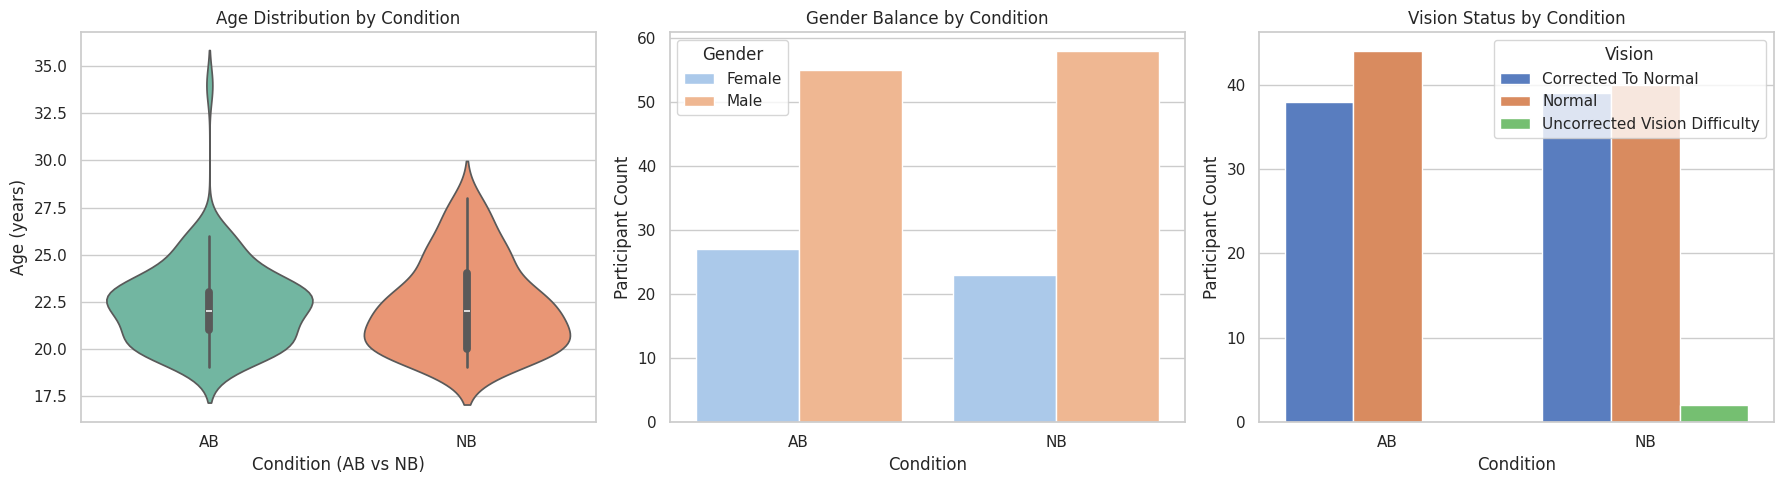

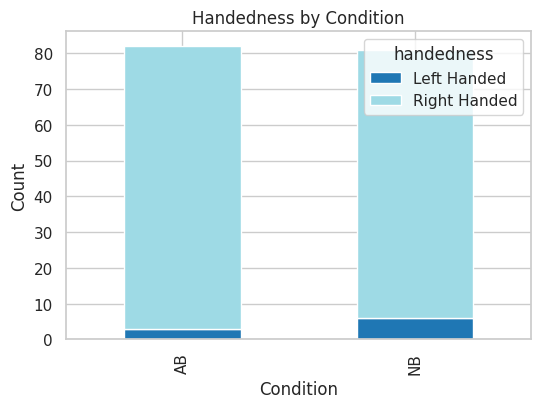

In [9]:
# Visualize demographic distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.violinplot(data=demo_df, x='condition', y='age', inner='box', palette='Set2', ax=axes[0])
axes[0].set_title('Age Distribution by Condition')
axes[0].set_xlabel('Condition (AB vs NB)')
axes[0].set_ylabel('Age (years)')

sns.countplot(data=demo_df, x='condition', hue='gender', palette='pastel', ax=axes[1])
axes[1].set_title('Gender Balance by Condition')
axes[1].set_xlabel('Condition')
axes[1].set_ylabel('Participant Count')
axes[1].legend(title='Gender')

sns.countplot(data=demo_df, x='condition', hue='vision', palette='muted', ax=axes[2])
axes[2].set_title('Vision Status by Condition')
axes[2].set_xlabel('Condition')
axes[2].set_ylabel('Participant Count')
axes[2].legend(title='Vision')

plt.tight_layout()
plt.show()

if handedness_counts.shape[1] > 1:
    handedness_counts.plot(kind='bar', stacked=True, figsize=(6, 4), colormap='tab20')
    plt.title('Handedness by Condition')
    plt.xlabel('Condition')
    plt.ylabel('Count')
    plt.show()
else:
    print('All recorded participants reported the same handedness, so no additional plot is shown.')

In [10]:
# Path to data directory
data_dir = 'BRSM data csv'

# List all CSV files in the directory
files = glob.glob(os.path.join(data_dir, '*.csv'))

all_data = []

for file in files:
    try:
        # Read the CSV file
        df = pd.read_csv(file)
        
        # Extract participant ID and Condition from filename
        filename = os.path.basename(file)
        # Filename pattern: sub100_AB_recognitionstage_...
        match = re.search(r'(sub\d+)_([A-Z]+)_', filename, re.IGNORECASE)
        if match:
            participant_id = match.group(1)
            condition = match.group(2).upper()  # Ensure 'AB' or 'NB'
        else:
            # Fallback or skip if pattern doesn't match
            print(f"Skipping file with unexpected name format: {filename}")
            continue
            
        # Add extracted info to DataFrame
        df['participant_id'] = participant_id
        df['condition'] = condition
        
        # Append to list
        all_data.append(df)
        
    except Exception as e:
        print(f"Error reading {file}: {e}")

# Concatenate all DataFrames
if all_data:
    combined_df = pd.concat(all_data, ignore_index=True)
    print(f"Loaded {len(all_data)} files into a single DataFrame with {len(combined_df)} rows.")
else:
    print("No data loaded.")

Skipping file with unexpected name format: sub133_AB _recognitionstage_2026-02-02_13h23.31.011.csv
Loaded 170 files into a single DataFrame with 7607 rows.
Loaded 170 files into a single DataFrame with 7607 rows.


# Preprocess Data

Filter for valid recognition trials. We expect rows where `recogloop.resp.keys` is populated (or `recogloop.resp.corr`).
We also extract the Target Type (BB/EM) from the `target_img` filename.

In [11]:
# Filter for rows that are part of the recognition loop and have a response
# The column 'recogloop.resp.keys' should be present and not null for valid trials
if 'recogloop.resp.keys' in combined_df.columns:
    recog_data = combined_df.dropna(subset=['recogloop.resp.keys']).copy()
else:
    print("Warning: 'recogloop.resp.keys' column not found!")
    recog_data = combined_df.copy()

# Extract Target Type (BB/EM) from 'target_img' column
# Example: frames\Vid1_EM_T.png -> EM
def extract_target_type(path):
    if pd.isna(path):
        return None
    match = re.search(r'_([A-Z]{2})_', str(path))
    if match:
        return match.group(1)
    return None

recog_data['target_type'] = recog_data['target_img'].apply(extract_target_type)

# Check unique target types extracted
print("Extracted Target Types:", recog_data['target_type'].unique())

Extracted Target Types: <StringArray>
['BB', 'EM']
Length: 2, dtype: str


# Visualize Accuracy

We calculate the mean accuracy (`recogloop.resp.corr`) grouped by Condition (AB/NB) and Target Type (BB/EM).

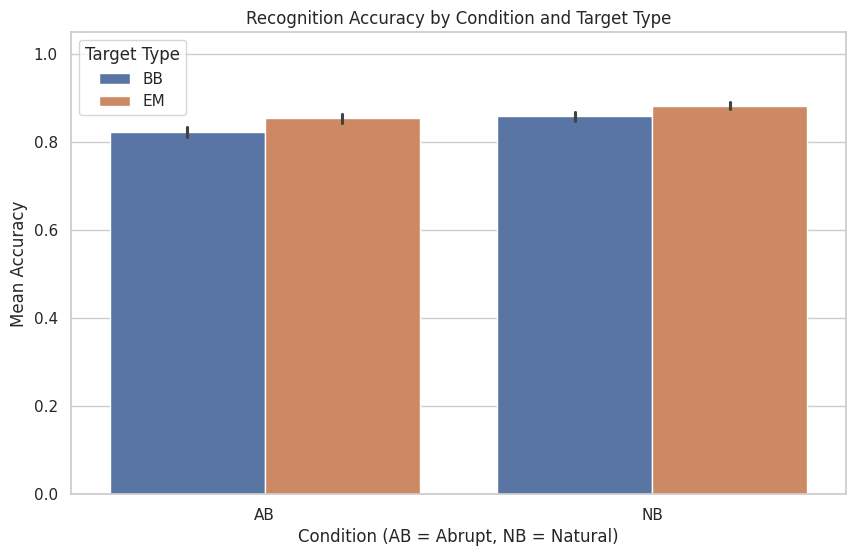

In [12]:
# Calculate mean accuracy per participant first, then average across participants
# Group by participant, condition, target_type
accuracy_per_participant = recog_data.groupby(['participant_id', 'condition', 'target_type'])['recogloop.resp.corr'].mean().reset_index()

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=accuracy_per_participant, x='condition', y='recogloop.resp.corr', hue='target_type', errorbar='se')
plt.title('Recognition Accuracy by Condition and Target Type')
plt.ylabel('Mean Accuracy')
plt.xlabel('Condition (AB = Abrupt, NB = Natural)')
plt.ylim(0, 1.05)
plt.legend(title='Target Type')
plt.show()

# Visualize Confidence

We calculate the mean confidence rating (`recogloop.conf_radio.response`) grouped by Condition and Target Type.

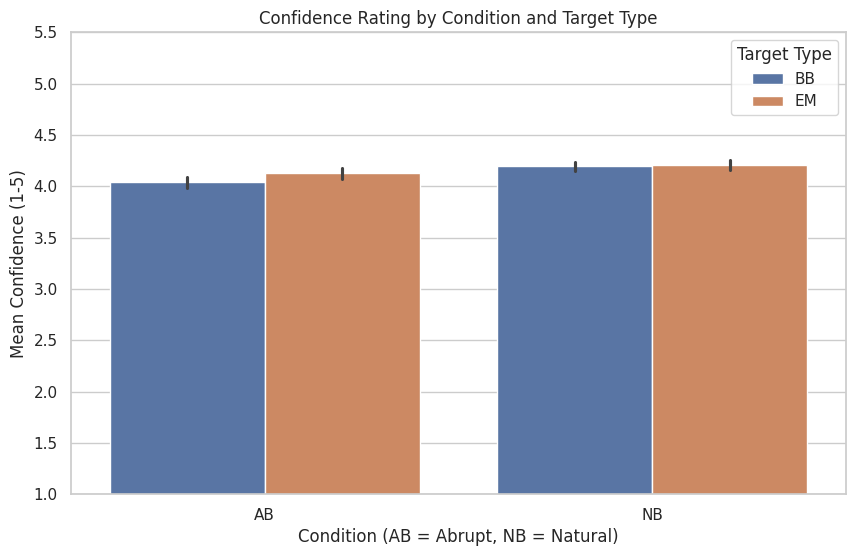

In [13]:
# Calculate mean confidence per participant
if 'recogloop.conf_radio.response' in recog_data.columns:
    confidence_per_participant = recog_data.groupby(['participant_id', 'condition', 'target_type'])['recogloop.conf_radio.response'].mean().reset_index()

    # Plot
    plt.figure(figsize=(10, 6))
    sns.barplot(data=confidence_per_participant, x='condition', y='recogloop.conf_radio.response', hue='target_type', errorbar='se')
    plt.title('Confidence Rating by Condition and Target Type')
    plt.ylabel('Mean Confidence (1-5)')
    plt.xlabel('Condition (AB = Abrupt, NB = Natural)')
    plt.ylim(1, 5.5)
    plt.legend(title='Target Type')
    plt.show()
else:
    print("Confidence column 'recogloop.conf_radio.response' not found.")

# Summary and Notes
- **Accuracy**: We visualized the recognition accuracy across the two conditions (Abrupt vs Natural) and two target types (Before Boundary vs Event Middle).
- **Confidence**: We examined the mean confidence ratings for the same groups.
- **Difficulty Levels**: The dataset provided does not contain explicit difficulty level labels for the lure images, so this factor was not included in the visualization.
